# Churn research: data audit and first hypotheses

## tl;dr
For snapshot SHA-256 `1f7dfa2170e2a15d16cb9ca78e45e88b77cc60b9eb1c1c05d89fbb480185a45c`: 3,150 customers, 495 churn labels (15.7%). The train split has 1,891 rows, 297 churn labels, no missing cells, 288 rows in duplicate-feature groups and 9 groups with conflicting labels. All notebook cells executed, and the three saved figures were checked for readability and agreement with the reported counts.

## Context & Methods
Source: [UCI Iranian Churn](https://archive.ics.uci.edu/dataset/563/iranian%2Bchurn%2Bdataset), CC BY 4.0. Predict churn at the end of month 12 using features aggregated over the first 9 months. This is a telecom benchmark, not a fintech sample.

### Key Assumptions
`Status` and `Customer Value` are excluded from primary models because their decision-time availability or meaning needs clarification. Repeated feature rows stay in one split. This dataset lacks row-level event timestamps, so the holdout is group-aware stratified rather than a time holdout. All target-aware EDA below uses train rows only.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from retention_lab.config import read_config
from retention_lab.data import TARGET, load_snapshot, model_features
from retention_lab.splitting import make_split_plan, plan_summary

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent
settings = read_config(project_root / "configs/full.toml").model_copy(
    update={"data_dir": project_root / "data"}
)
plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11, "axes.grid": True})

Matplotlib is building the font cache; this may take a moment.


## Data
Load the cached snapshot created by `retention-lab fetch-data`; this notebook never downloads or silently changes it. Record the digest for reproducibility.

In [2]:
frame, manifest = load_snapshot(settings)
plan = make_split_plan(frame, seed=settings.seed)
train_ids = plan.loc[plan["split"].eq("train"), "row_id"].to_numpy()
train = frame.iloc[train_ids].copy()
print(
    {"source": manifest.source_url, "snapshot_sha256": manifest.sha256, "rows": manifest.row_count}
)
display(pd.DataFrame(plan_summary(plan)["counts"]).T)

{'source': 'https://archive.ics.uci.edu/dataset/563/iranian%2Bchurn%2Bdataset', 'snapshot_sha256': '1f7dfa2170e2a15d16cb9ca78e45e88b77cc60b9eb1c1c05d89fbb480185a45c', 'rows': 3150}


,rows,positives,prevalence,groups
train,1891.0,297.0,0.157060,1702.0
calibration,313.0,49.0,0.156550,278.0
validation,471.0,73.0,0.154989,420.0
test,475.0,76.0,0.160000,426.0


### Audit train data
Inspect schema, missing values, duplicate groups and broad ranges before trying models. Avoid fitting or selecting features from the held-out subsets.

In [3]:
feature_frame = model_features(train)
audit = pd.DataFrame(
    {
        "dtype": feature_frame.dtypes.astype(str),
        "missing": feature_frame.isna().sum(),
        "unique": feature_frame.nunique(),
    }
)
display(audit)
display(feature_frame.describe().T[["count", "mean", "std", "min", "50%", "max"]])
train_plan = plan.loc[plan["split"].eq("train")]
duplicate_rows = int(train_plan["duplicate_group"].duplicated(keep=False).sum())
conflicting_groups = int((train_plan.groupby("duplicate_group")[TARGET].nunique() > 1).sum())
print(
    {"duplicate_feature_rows": duplicate_rows, "groups_with_conflicting_labels": conflicting_groups}
)

,dtype,missing,unique
call_failure,int64,0,36
complains,int64,0,2
subscription_length,int64,0,44
charge_amount,int64,0,11
seconds_of_use,int64,0,1230
frequency_of_use,int64,0,226
frequency_of_sms,int64,0,345
distinct_called_numbers,int64,0,89
age_group,int64,0,5
tariff_plan,int64,0,2


,count,mean,std,min,50%,max
call_failure,1891.0,7.781597,7.221104,0.0,6.0,36.0
complains,1891.0,0.077208,0.266992,0.0,0.0,1.0
subscription_length,1891.0,32.515600,8.504163,3.0,35.0,47.0
charge_amount,1891.0,0.953993,1.527698,0.0,0.0,10.0
seconds_of_use,1891.0,4490.055526,4186.806517,0.0,3035.0,16640.0
frequency_of_use,1891.0,70.060286,57.064009,0.0,55.0,254.0
frequency_of_sms,1891.0,74.739820,114.977196,0.0,21.0,522.0
distinct_called_numbers,1891.0,23.938657,17.404294,0.0,21.0,93.0
age_group,1891.0,2.819143,0.909138,1.0,3.0,5.0
tariff_plan,1891.0,1.083025,0.275993,1.0,1.0,2.0


{'duplicate_feature_rows': 288, 'groups_with_conflicting_labels': 9}


## Results
The figures are descriptive, train-only checks. Differences between churn classes do not establish a causal relationship.

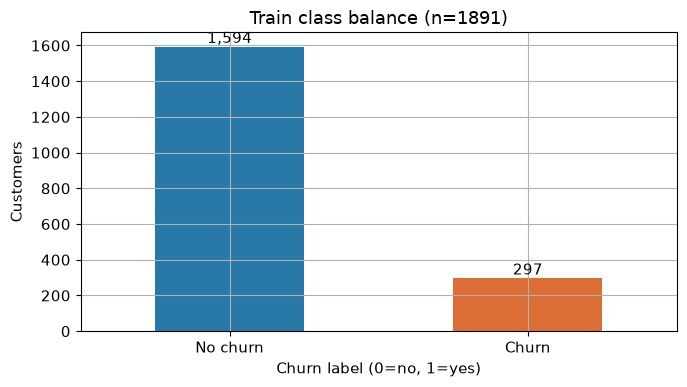

Train churn prevalence: 15.7%


In [4]:
counts = train[TARGET].value_counts().reindex([0, 1], fill_value=0)
ax = counts.plot.bar(color=["#2878A8", "#DB6D35"])
ax.set(
    title=f"Train class balance (n={len(train)})",
    xlabel="Churn label (0=no, 1=yes)",
    ylabel="Customers",
)
ax.set_xticklabels(["No churn", "Churn"], rotation=0)
for index, value in enumerate(counts):
    ax.text(index, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()
print(f"Train churn prevalence: {train[TARGET].mean():.1%}")

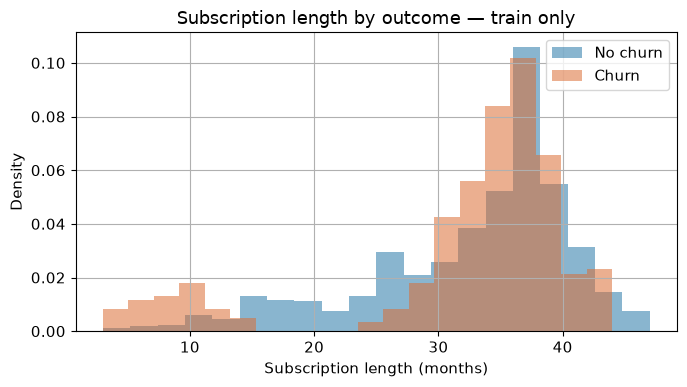

In [5]:
fig, ax = plt.subplots()
for label, name, color in [(0, "No churn", "#2878A8"), (1, "Churn", "#DB6D35")]:
    ax.hist(
        train.loc[train[TARGET].eq(label), "subscription_length"],
        bins=20,
        alpha=0.55,
        density=True,
        label=name,
        color=color,
    )
ax.set(
    title="Subscription length by outcome — train only",
    xlabel="Subscription length (months)",
    ylabel="Density",
)
ax.legend()
plt.tight_layout()
plt.show()

,churn_rate,churn_count,customers
complains,,,
0,0.098567,172,1745
1,0.856164,125,146


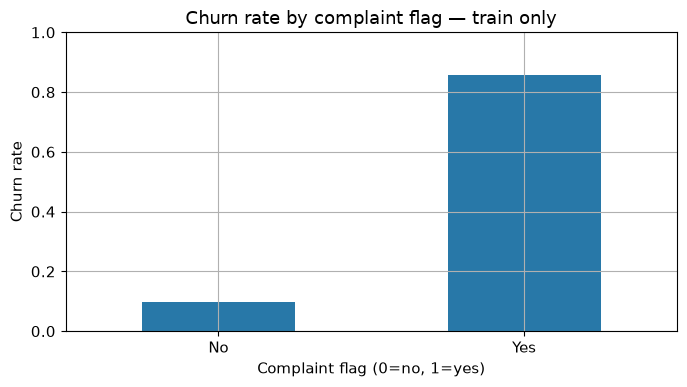

In [6]:
complaint_summary = train.groupby("complains", observed=True)[TARGET].agg(["mean", "sum", "count"])
display(
    complaint_summary.rename(
        columns={"mean": "churn_rate", "sum": "churn_count", "count": "customers"}
    )
)
ax = complaint_summary["mean"].plot.bar(color="#2878A8")
ax.set(
    title="Churn rate by complaint flag — train only",
    xlabel="Complaint flag (0=no, 1=yes)",
    ylabel="Churn rate",
    ylim=(0, 1),
)
ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

## Takeaways
On train, churn is 125/146 (85.6%) when `complains=1` and 172/1745 (9.9%) when `complains=0`. This is an association, not a causal effect. Verify how and when complaints were recorded before treating the feature as decision-time safe. No target-aware inspection of validation or test rows was used for these observations.

Next: review the rendered charts, then compare a dummy classifier and simple train-only preprocessing pipelines under the same saved split. If the snapshot digest changes, recalculate these statements.